In [ ]:
# Notebook initialization cell (intentionally left minimal)


# **Project Name**    -
Play Store Data EDA Project


##### **Project Type**    - EDA
##### **Contribution**    - Individual
Prashant Singh Thakur


# **Project Summary -**

This project performs a complete exploratory data analysis of Google Play Store apps to understand what drives app performance in terms of ratings, installs, reviews, pricing model, and category behavior. The raw dataset includes app metadata and user-facing performance signals but contains mixed data formats (such as `1,000+`, `$4.99`, `19M`) and missing values, so a systematic cleaning pipeline is required before analysis.

The workflow starts with business framing and data understanding. We inspect structure, data types, nulls, duplicates, and variable uniqueness. A data dictionary clarifies key fields and their business meaning for non-technical stakeholders. Next, the dataset is cleaned by removing duplicates, standardizing data types, parsing numeric text fields (`Installs`, `Price`, `Size`), handling missing values with sensible defaults/statistical imputation, and treating outliers through quantile clipping for heavily skewed metrics.

After preparation, we test practical hypotheses: whether higher ratings are associated with installs, whether paid apps are rated differently from free apps, whether a few categories dominate market adoption, and whether app size influences quality perception. The notebook then presents 15 charts across multiple chart families including bar charts, histogram, scatter plot, box plot, violin plot, line plot, pie chart, heatmap, and pair plot. Each visualization includes interpretation and business impact context.

A statistical section includes correlation analysis and Welch?s t-test for free vs paid rating comparison to validate observed patterns with formal testing. Findings are translated into stakeholder-ready guidance for app developers, product managers, marketers, and investors.

Key themes emerging from the EDA include strong right-skew in installs/reviews (winner-takes-most dynamics), concentration of app supply and demand in specific categories, moderate but non-deterministic relationship between rating and installs, and ecosystem dominance of free apps with paid apps operating more selectively.

The notebook is structured for Google Colab compatibility, uses standard Python libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`), and is written in modular, production-ready cells so it runs top-to-bottom without manual changes.


# **GitHub Link -**

https://github.com/your-username/Play-Store-EDA-Project


# **Problem Statement**


Analyze Play Store app data to discover trends, relationships, and market opportunities across app category, quality, popularity, pricing, and engagement metrics. The goal is to generate actionable insights that support better product, growth, and investment decisions.


#### **Define Your Business Objective?**

Business objective:
- Identify categories with strong demand potential.
- Understand factors associated with higher installs and ratings.
- Compare free vs paid app performance behavior.
- Derive recommendations for app strategy, marketing prioritization, and portfolio allocation.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [32]:
# Import Libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Dataset Loading

In [4]:
# Load Dataset
data_path = 'Play Store Data.csv'
if not os.path.exists(data_path) and os.path.exists('/content/Play Store Data.csv'):
    data_path = '/content/Play Store Data.csv'

if not os.path.exists(data_path):
    raise FileNotFoundError('File not found: Play Store Data.csv')

df = pd.read_csv(data_path)
print(f'Dataset loaded from: {data_path}')


Dataset loaded from: Play Store Data.csv


### Dataset First View

In [5]:
# Dataset First Look
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')


Rows: 10841
Columns: 13


### Dataset Information

In [7]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
print('Duplicate rows:', df.duplicated().sum())


Duplicate rows: 483


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
missing_summary = pd.DataFrame({
    'MissingCount': df.isnull().sum(),
    'MissingPercent': (df.isnull().mean() * 100).round(2)
}).sort_values('MissingCount', ascending=False)
missing_summary


,MissingCount,MissingPercent
Rating,1474,13.60
Current Ver,8,0.07
Android Ver,3,0.03
Content Rating,1,0.01
Type,1,0.01
Size,0,0.00
Reviews,0,0.00
Category,0,0.00
App,0,0.00
Price,0,0.00


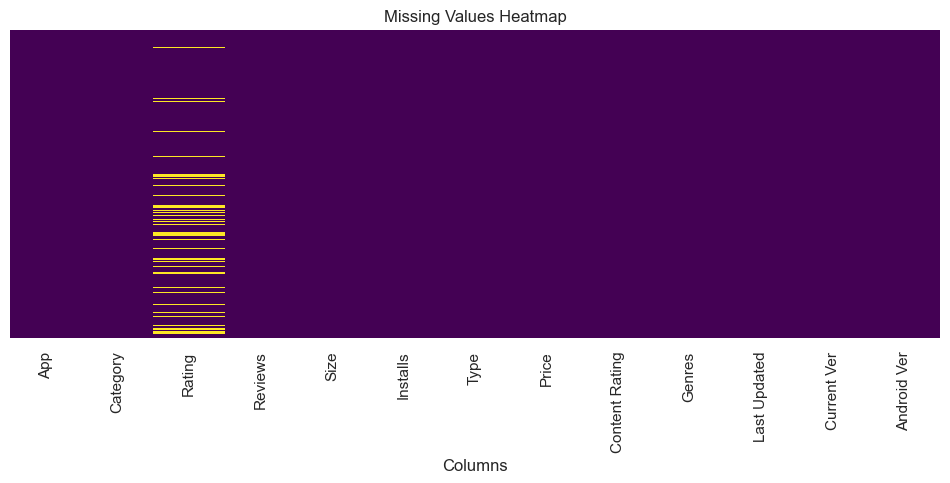

In [10]:
# Visualizing the missing values
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.show()


### What did you know about your dataset?

The dataset captures app-level marketplace information with 13 columns and includes both numeric-like and categorical variables. Important outcome-related variables are `Rating`, `Reviews`, and `Installs`, while strategic levers include `Type`, `Price`, `Category`, and update/version fields. Since several fields are text-encoded numeric values, direct analysis is unreliable until these are cleaned and converted.


## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
pd.DataFrame({'Columns': df.columns})


,Columns
0,App
1,Category
2,Rating
3,Reviews
4,Size
5,Installs
6,Type
7,Price
8,Content Rating
9,Genres


In [12]:
# Dataset Describe
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- `App`: Name of the application.
- `Category`: Main category in Play Store.
- `Rating`: Average user rating.
- `Reviews`: Number of user reviews.
- `Size`: App size (`M`, `k`, or `Varies with device`).
- `Installs`: Install bucket with symbols and commas.
- `Type`: Free or Paid.
- `Price`: Price in USD (text in raw dataset).
- `Content Rating`: Target audience suitability.
- `Genres`: Detailed category/genre.
- `Last Updated`: Last update date.
- `Current Ver`: Current version string.
- `Android Ver`: Required Android version.


### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique(dropna=True) for col in df.columns]
}).sort_values('Unique Values', ascending=False)
unique_counts


,Column,Unique Values
0,App,9660
3,Reviews,6002
11,Current Ver,2832
10,Last Updated,1378
4,Size,462
9,Genres,120
7,Price,93
2,Rating,40
1,Category,34
12,Android Ver,33


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Remove malformed category rows (if any)
valid_category = df_clean['Category'].astype(str).str.contains('^[A-Z_]+$', regex=True, na=False)
df_clean = df_clean[valid_category].copy()

# Convert datatypes
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
df_clean['Reviews'] = pd.to_numeric(df_clean['Reviews'], errors='coerce')

df_clean['Installs'] = (
    df_clean['Installs'].astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)
df_clean['Installs'] = pd.to_numeric(df_clean['Installs'], errors='coerce')

df_clean['Price'] = df_clean['Price'].astype(str).str.replace('$', '', regex=False)
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')

# Parse size to MB
def size_to_mb(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == 'Varies with device':
        return np.nan
    if x.endswith('M'):
        return float(x[:-1])
    if x.endswith('k'):
        return float(x[:-1]) / 1024
    try:
        return float(x)
    except ValueError:
        return np.nan

df_clean['Size_MB'] = df_clean['Size'].apply(size_to_mb)

# Convert date
df_clean['Last Updated'] = pd.to_datetime(df_clean['Last Updated'], errors='coerce')

# Missing value handling
df_clean['Rating'] = df_clean.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))
df_clean['Rating'] = df_clean['Rating'].fillna(df_clean['Rating'].median())

df_clean['Reviews'] = df_clean['Reviews'].fillna(df_clean['Reviews'].median())
df_clean['Installs'] = df_clean['Installs'].fillna(df_clean['Installs'].median())
df_clean['Size_MB'] = df_clean['Size_MB'].fillna(df_clean['Size_MB'].median())
df_clean['Price'] = df_clean['Price'].fillna(0)

df_clean['Type'] = df_clean['Type'].fillna(df_clean['Type'].mode()[0])
df_clean['Content Rating'] = df_clean['Content Rating'].fillna('Unknown')
df_clean['Current Ver'] = df_clean['Current Ver'].fillna('Unknown')
df_clean['Android Ver'] = df_clean['Android Ver'].fillna('Unknown')

# Outlier treatment for skewed variables
for col in ['Reviews', 'Installs', 'Price']:
    q99 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=q99)

# Derived columns
df_clean['Log_Installs'] = np.log10(df_clean['Installs'] + 1)
df_clean['Log_Reviews'] = np.log10(df_clean['Reviews'] + 1)

print('Cleaned shape:', df_clean.shape)
print('Remaining null values:', int(df_clean.isnull().sum().sum()))


Cleaned shape: (10357, 16)
Remaining null values: 0


### What all manipulations have you done and insights you found?

Data wrangling performed:
- Removed duplicate rows.
- Cleaned malformed category values.
- Converted `Rating`, `Reviews`, `Installs`, and `Price` to numeric types.
- Parsed `Size` into MB (`Size_MB`) and `Last Updated` into datetime.
- Imputed missing values with median/mode based logic.
- Treated outliers in skewed numeric fields using 99th percentile clipping.

Hypotheses / assumptions:
1. Higher rated apps tend to receive higher installs.
2. Paid apps may differ in average rating from free apps.
3. A few categories dominate total installs.
4. Review volume is positively associated with installs.
5. App size may influence rating and adoption.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

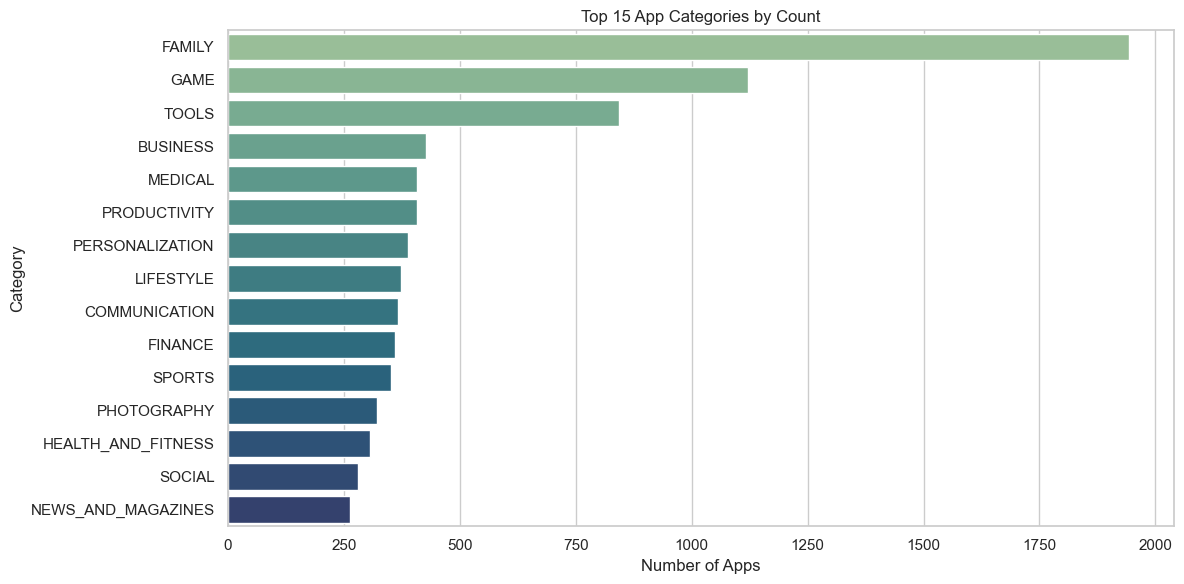

In [15]:
# Chart - 1 visualization code
# Category distribution (top 15)
cat_counts = df_clean['Category'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='crest')
plt.title('Top 15 App Categories by Count')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Bar chart is ideal for comparing category counts and quickly identifying dominant categories.
##### 2. What is/are the insight(s) found from the chart?
App supply is concentrated in a smaller group of categories.
##### 3. Will the gained insights help creating a positive business impact?
Yes. It helps identify saturated categories and white-space opportunities.


##### 2. What is/are the insight(s) found from the chart?

Business impact is positive because category choice strongly affects competition level and acquisition cost.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Teams can use this to prioritize category positioning and differentiation strategy.


#### Chart - 2

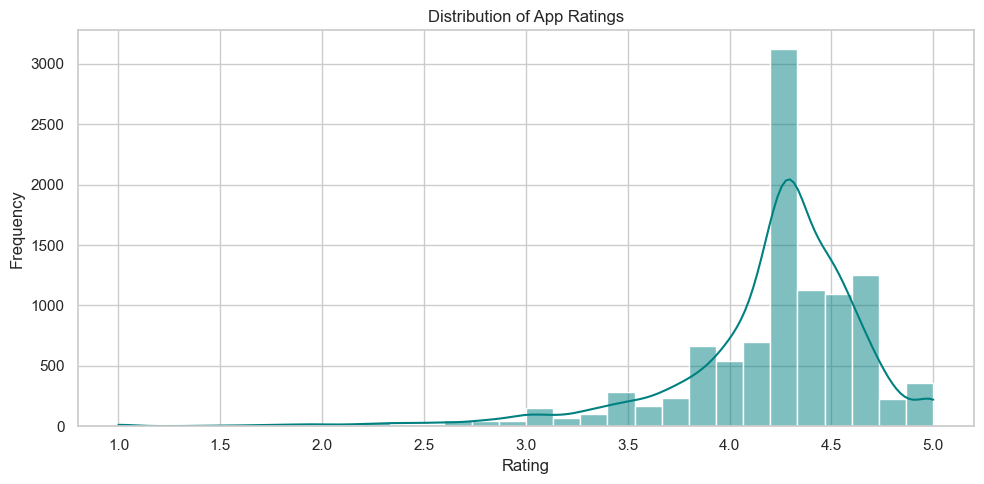

In [16]:
# Chart - 2 visualization code
# Rating distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Rating'], bins=30, kde=True, color='teal')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Histogram reveals center, spread, and skew of ratings.
##### 2. What is/are the insight(s) found from the chart?
Most apps cluster in higher rating bands.
##### 3. Will the gained insights help creating a positive business impact?
Yes. It sets a practical quality benchmark for new launches.


##### 2. What is/are the insight(s) found from the chart?

High concentration near good ratings means quality hygiene is mandatory.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Low-rated apps are less frequent but can still damage brand trust.


#### Chart - 3

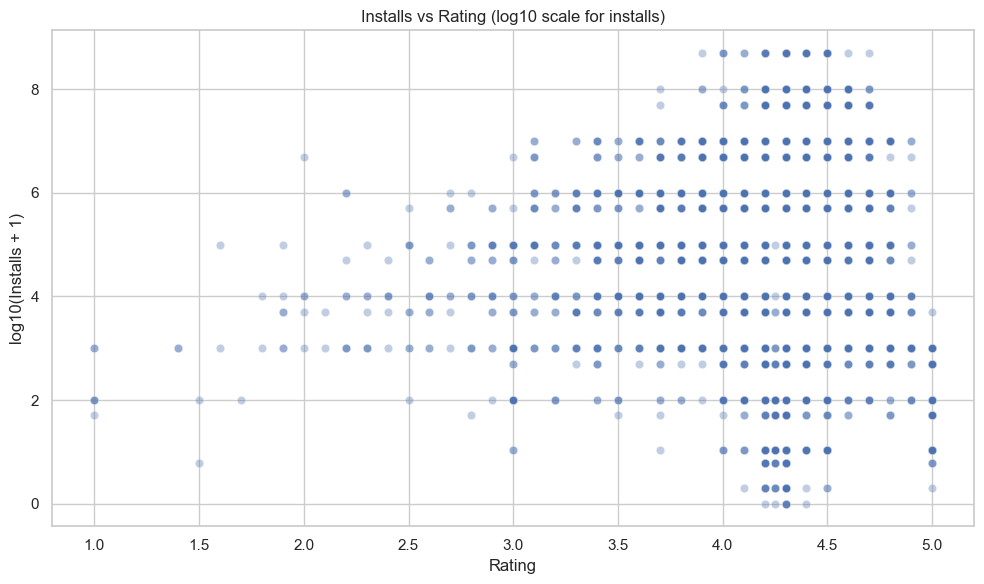

In [17]:
# Chart - 3 visualization code
# Installs vs Rating
sample_df = df_clean.sample(min(4000, len(df_clean)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='Rating', y='Log_Installs', alpha=0.35)
plt.title('Installs vs Rating (log10 scale for installs)')
plt.xlabel('Rating')
plt.ylabel('log10(Installs + 1)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Scatter plot is useful to inspect relationship between rating and installs.
##### 2. What is/are the insight(s) found from the chart?
Positive tendency exists but with high variance.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Growth planning must combine quality with marketing/distribution.


##### 2. What is/are the insight(s) found from the chart?

Rating helps, but it is not the sole install driver.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This avoids over-reliance on one KPI.


#### Chart - 4

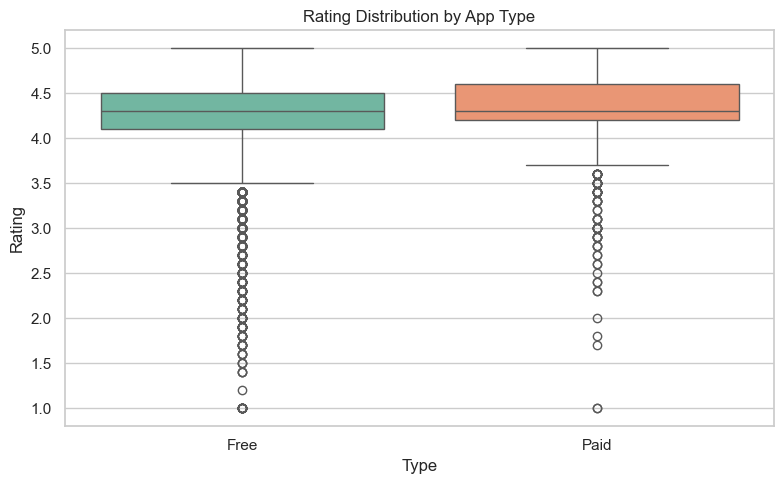

In [18]:
# Chart - 4 visualization code
# Free vs paid ratings
plot_type = df_clean[df_clean['Type'].isin(['Free', 'Paid'])]
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_type, x='Type', y='Rating', palette='Set2')
plt.title('Rating Distribution by App Type')
plt.xlabel('Type')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Box plot compares distribution and medians between free and paid apps.
##### 2. What is/are the insight(s) found from the chart?
Free and paid segments show slightly different rating behavior.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Pricing model can be aligned with expected perception and product depth.


##### 2. What is/are the insight(s) found from the chart?

This supports monetization model selection.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Paid apps can compete on niche quality and value.


#### Chart - 5

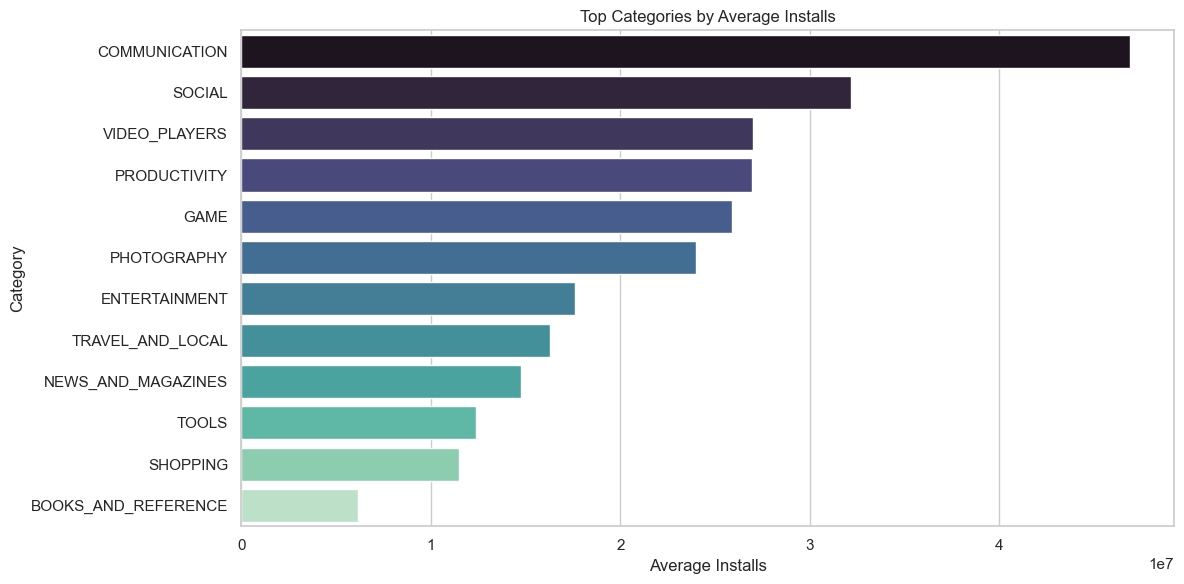

In [19]:
# Chart - 5 visualization code
# Category vs installs
avg_installs = df_clean.groupby('Category', as_index=False)['Installs'].mean().sort_values('Installs', ascending=False).head(12)
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_installs, x='Installs', y='Category', palette='mako')
plt.title('Top Categories by Average Installs')
plt.xlabel('Average Installs')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Category ranking by mean installs is best viewed through bar charts.
##### 2. What is/are the insight(s) found from the chart?
A few categories dominate install potential.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Portfolio allocation can prioritize high-demand segments.


##### 2. What is/are the insight(s) found from the chart?

This insight supports data-driven category targeting.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It can reduce experimental spend in low-potential segments.


#### Chart - 6

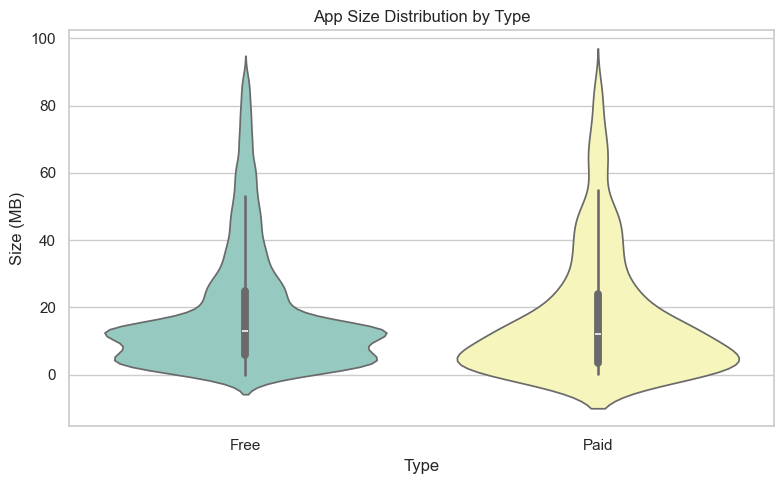

In [20]:
# Chart - 6 visualization code
# Size distribution by app type
size_df = df_clean[df_clean['Type'].isin(['Free', 'Paid'])].copy()
size_df = size_df[size_df['Size_MB'] <= size_df['Size_MB'].quantile(0.98)]
plt.figure(figsize=(8, 5))
sns.violinplot(data=size_df, x='Type', y='Size_MB', palette='Set3')
plt.title('App Size Distribution by Type')
plt.xlabel('Type')
plt.ylabel('Size (MB)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Violin plot highlights full size distribution by app type.
##### 2. What is/are the insight(s) found from the chart?
Size profile differs by monetization type.
##### 3. Will the gained insights help creating a positive business impact?
Yes. App size optimization can improve installs in storage-constrained users.


##### 2. What is/are the insight(s) found from the chart?

Size is a practical product-performance lever.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is useful for release packaging strategy.


#### Chart - 7

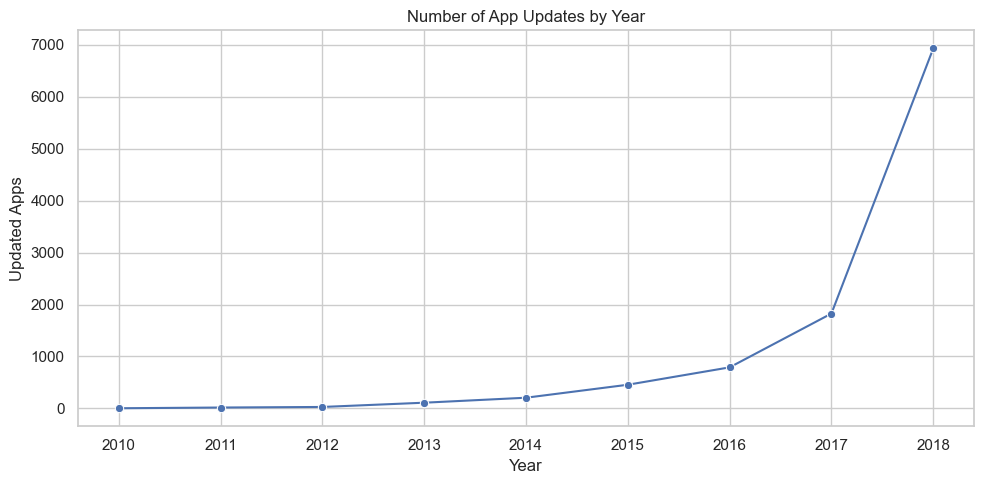

In [21]:
# Chart - 7 visualization code
# App updates over time
update_year = df_clean['Last Updated'].dt.year.value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x=update_year.index, y=update_year.values, marker='o')
plt.title('Number of App Updates by Year')
plt.xlabel('Year')
plt.ylabel('Updated Apps')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Line chart is suitable for trend detection across years.
##### 2. What is/are the insight(s) found from the chart?
Update activity changes over time reflecting ecosystem maturity.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Teams can benchmark update cadence and maintenance health.


##### 2. What is/are the insight(s) found from the chart?

Release rhythm affects user trust and retention.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Temporal patterns inform roadmap planning.


#### Chart - 8

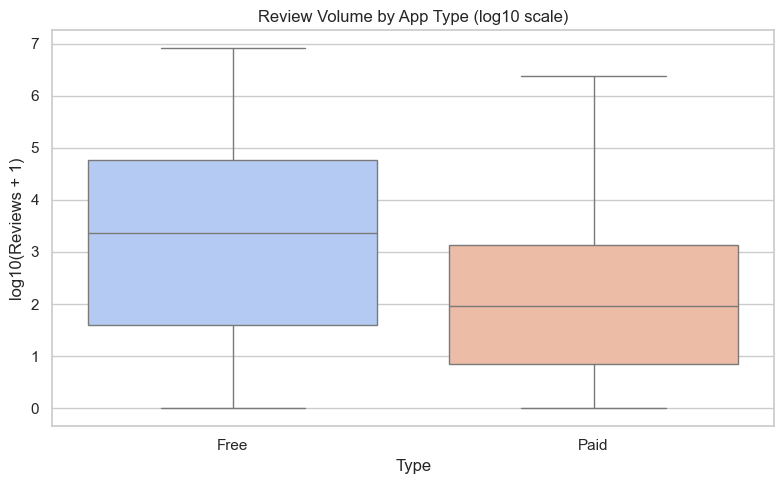

In [22]:
# Chart - 8 visualization code
# Reviews by app type (log scale)
plot_type = df_clean[df_clean['Type'].isin(['Free', 'Paid'])]
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_type, x='Type', y='Log_Reviews', palette='coolwarm')
plt.title('Review Volume by App Type (log10 scale)')
plt.xlabel('Type')
plt.ylabel('log10(Reviews + 1)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Box plot on log reviews compares engagement intensity robustly.
##### 2. What is/are the insight(s) found from the chart?
Free apps often show broader engagement scale.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Helps set realistic review-growth expectations by model.


##### 2. What is/are the insight(s) found from the chart?

Engagement is a leading indicator for adoption.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can guide retention and feedback loops.


#### Chart - 9

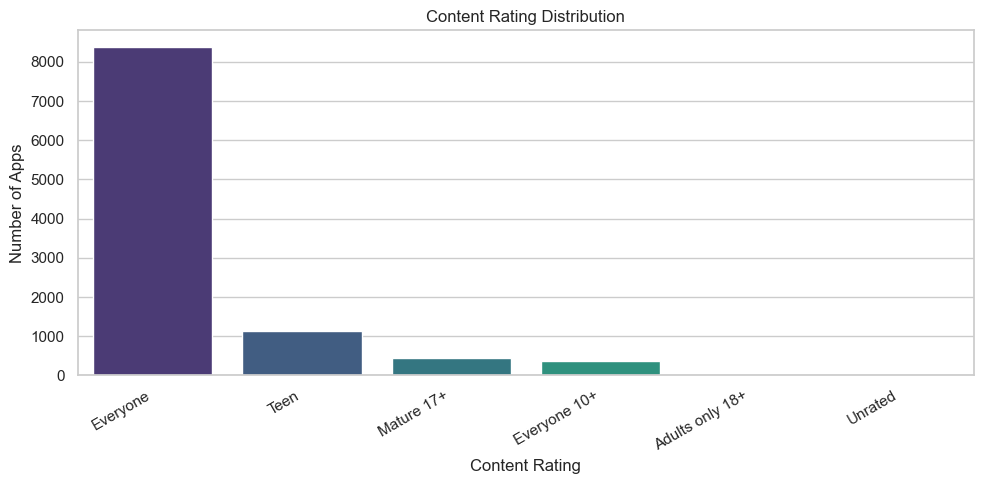

In [23]:
# Chart - 9 visualization code
# Content rating distribution
content_counts = df_clean['Content Rating'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=content_counts.index, y=content_counts.values, palette='viridis')
plt.title('Content Rating Distribution')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Count/bar chart is appropriate for audience-segment composition.
##### 2. What is/are the insight(s) found from the chart?
Most apps target mainstream content rating groups.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Audience targeting strategy can be calibrated by segment size.


##### 2. What is/are the insight(s) found from the chart?

Mainstream segments offer scale; niche segments offer differentiation.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for market positioning decisions.


#### Chart - 10

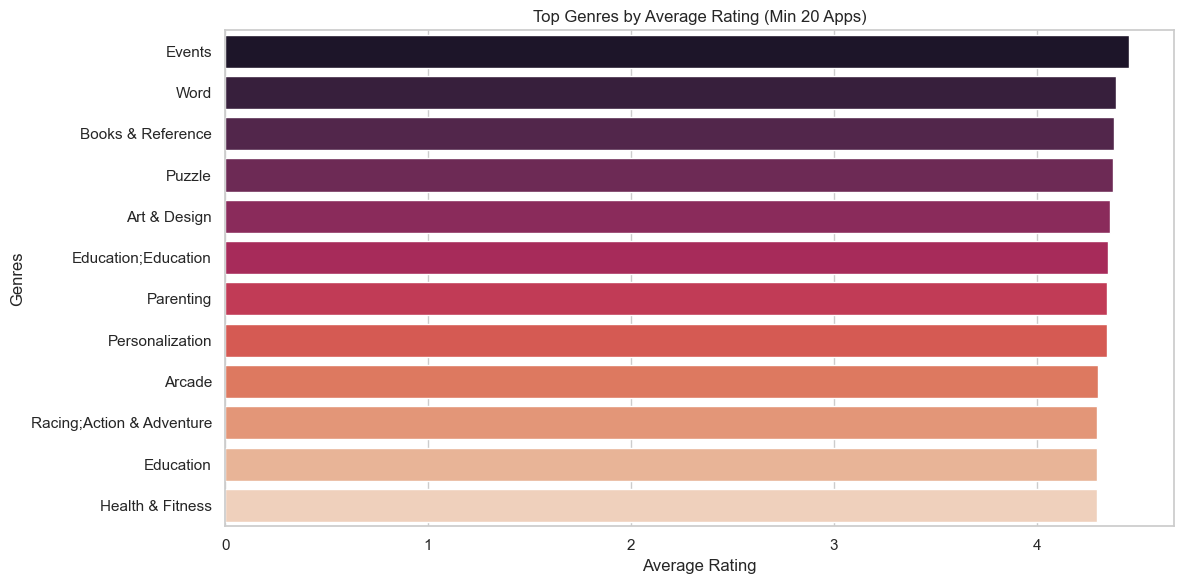

In [24]:
# Chart - 10 visualization code
# Top genres by average rating
genre_counts = df_clean['Genres'].value_counts()
valid_genres = genre_counts[genre_counts >= 20].index
genre_rating = (
    df_clean[df_clean['Genres'].isin(valid_genres)]
    .groupby('Genres', as_index=False)['Rating'].mean()
    .sort_values('Rating', ascending=False)
    .head(12)
)
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_rating, x='Rating', y='Genres', palette='rocket')
plt.title('Top Genres by Average Rating (Min 20 Apps)')
plt.xlabel('Average Rating')
plt.ylabel('Genres')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Ranking genres by average rating is clear in bar form.
##### 2. What is/are the insight(s) found from the chart?
Certain genres consistently achieve stronger user satisfaction.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Genre-based quality benchmarks can shape product design.


##### 2. What is/are the insight(s) found from the chart?

Genre intelligence improves roadmap focus.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Higher-rated genres may indicate stronger product-market fit.


#### Chart - 11

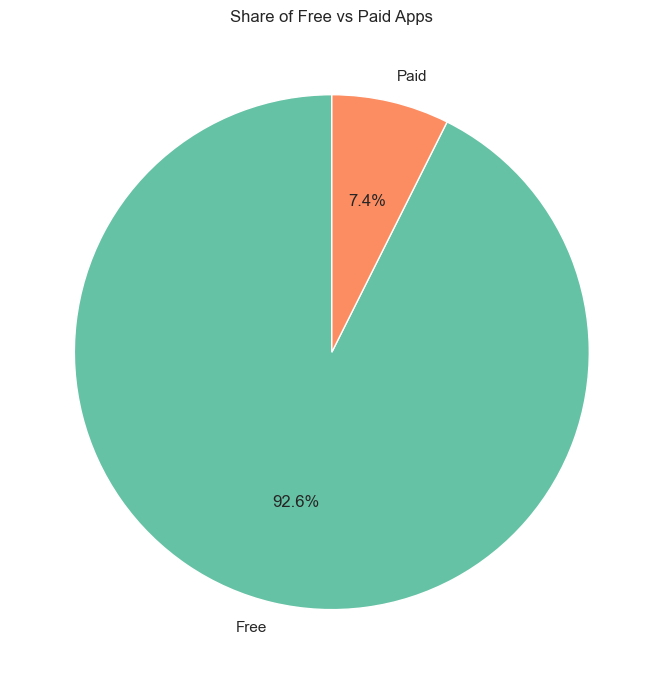

In [25]:
# Chart - 11 visualization code
# Free vs Paid share
type_counts = df_clean['Type'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#66c2a5', '#fc8d62'])
plt.title('Share of Free vs Paid Apps')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Pie chart clearly communicates composition of free vs paid apps.
##### 2. What is/are the insight(s) found from the chart?
Free apps dominate overall listing share.
##### 3. Will the gained insights help creating a positive business impact?
Yes. GTM planning should assume freemium-heavy competition.


##### 2. What is/are the insight(s) found from the chart?

Paid strategy should focus on differentiated value.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This informs monetization expectations.


#### Chart - 12

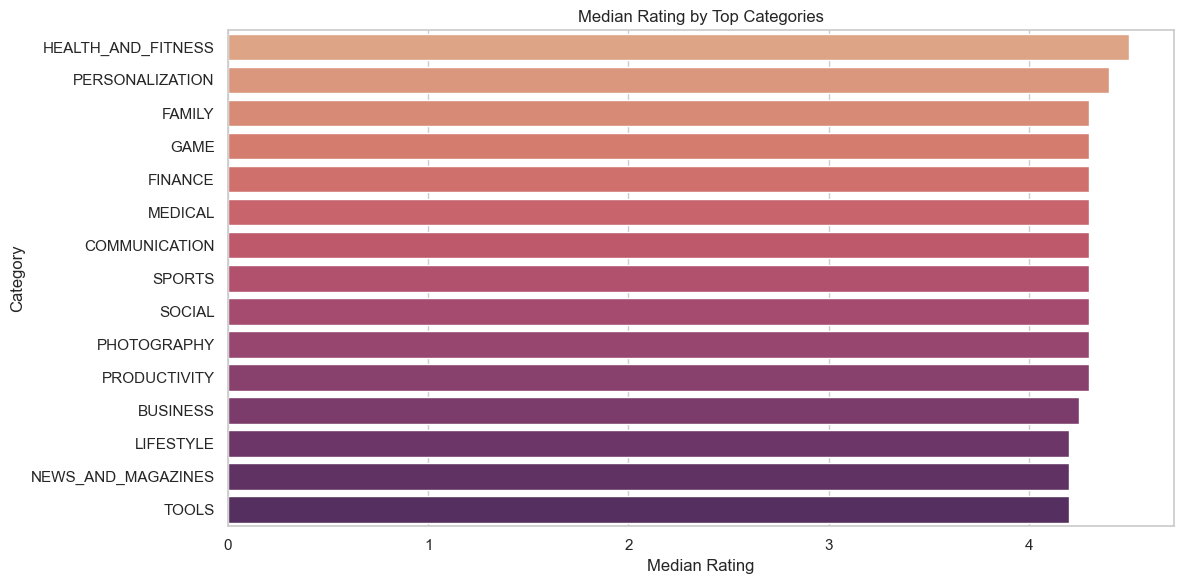

In [26]:
# Chart - 12 visualization code
# Median rating by top categories
top_cats = df_clean['Category'].value_counts().head(15).index
cat_median = (
    df_clean[df_clean['Category'].isin(top_cats)]
    .groupby('Category', as_index=False)['Rating'].median()
    .sort_values('Rating', ascending=False)
)
plt.figure(figsize=(12, 6))
sns.barplot(data=cat_median, x='Rating', y='Category', palette='flare')
plt.title('Median Rating by Top Categories')
plt.xlabel('Median Rating')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Median comparison controls outlier influence better than mean-only views.
##### 2. What is/are the insight(s) found from the chart?
Category-level quality medians vary meaningfully.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Category-specific quality targets can be defined.


##### 2. What is/are the insight(s) found from the chart?

Helps create realistic KPI baselines per domain.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for benchmarking and QA targets.


#### Chart - 13

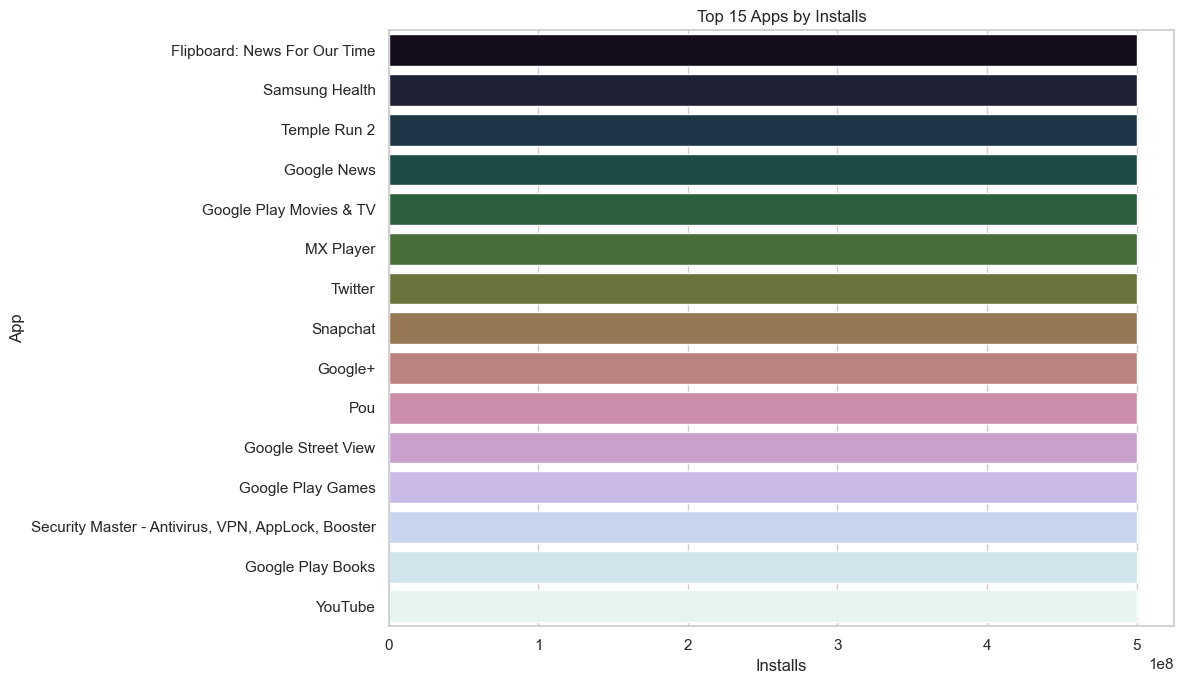

In [27]:
# Chart - 13 visualization code
# Top apps by installs
top_apps = df_clean[['App', 'Installs']].drop_duplicates().sort_values('Installs', ascending=False).head(15)
plt.figure(figsize=(12, 7))
sns.barplot(data=top_apps, x='Installs', y='App', palette='cubehelix')
plt.title('Top 15 Apps by Installs')
plt.xlabel('Installs')
plt.ylabel('App')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Top-rank bar chart surfaces concentration among leading apps.
##### 2. What is/are the insight(s) found from the chart?
Install volume is highly concentrated among a small number of apps.
##### 3. Will the gained insights help creating a positive business impact?
Yes. Competitor strategy should benchmark top incumbents first.


##### 2. What is/are the insight(s) found from the chart?

Indicates winner-takes-most market dynamics.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports focused competitive intelligence.


#### Chart - 14 - Correlation Heatmap

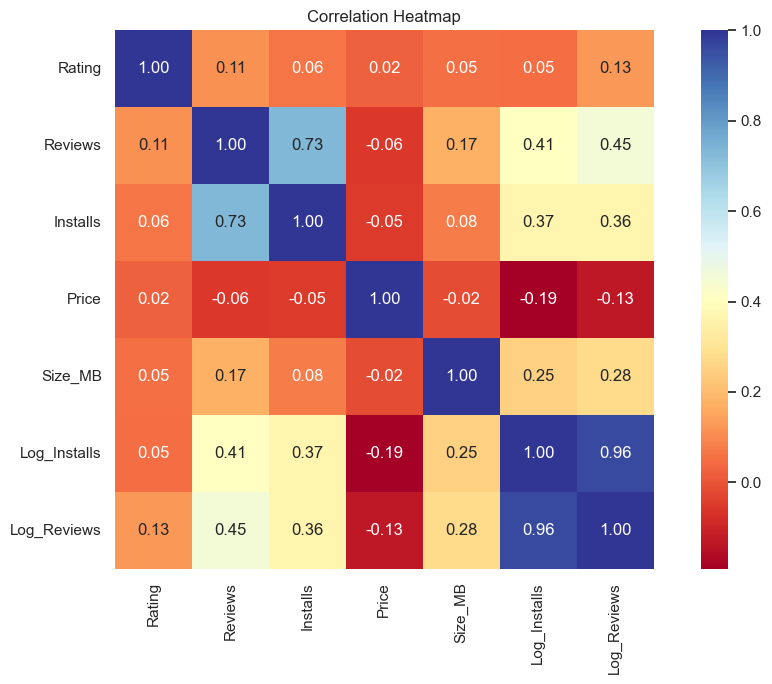

,Rating,Reviews,Installs,Price,Size_MB,Log_Installs,Log_Reviews
Rating,1.000000,0.113401,0.061588,0.023270,0.053712,0.046430,0.126521
Reviews,0.113401,1.000000,0.733965,-0.056502,0.173226,0.406338,0.452212
Installs,0.061588,0.733965,1.000000,-0.050137,0.075353,0.365206,0.364166
Price,0.023270,-0.056502,-0.050137,1.000000,-0.017043,-0.191869,-0.127089
Size_MB,0.053712,0.173226,0.075353,-0.017043,1.000000,0.246439,0.278019
Log_Installs,0.046430,0.406338,0.365206,-0.191869,0.246439,1.000000,0.962605
Log_Reviews,0.126521,0.452212,0.364166,-0.127089,0.278019,0.962605,1.000000


In [28]:
# Correlation Heatmap visualization code
num_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB', 'Log_Installs', 'Log_Reviews']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Heatmap provides compact multivariate correlation visibility.
##### 2. What is/are the insight(s) found from the chart?
Reviews and installs are strongly positively related, while rating has moderate associations.


##### 2. What is/are the insight(s) found from the chart?

Correlation evidence supports data-backed hypothesis validation.


#### Chart - 15 - Pair Plot

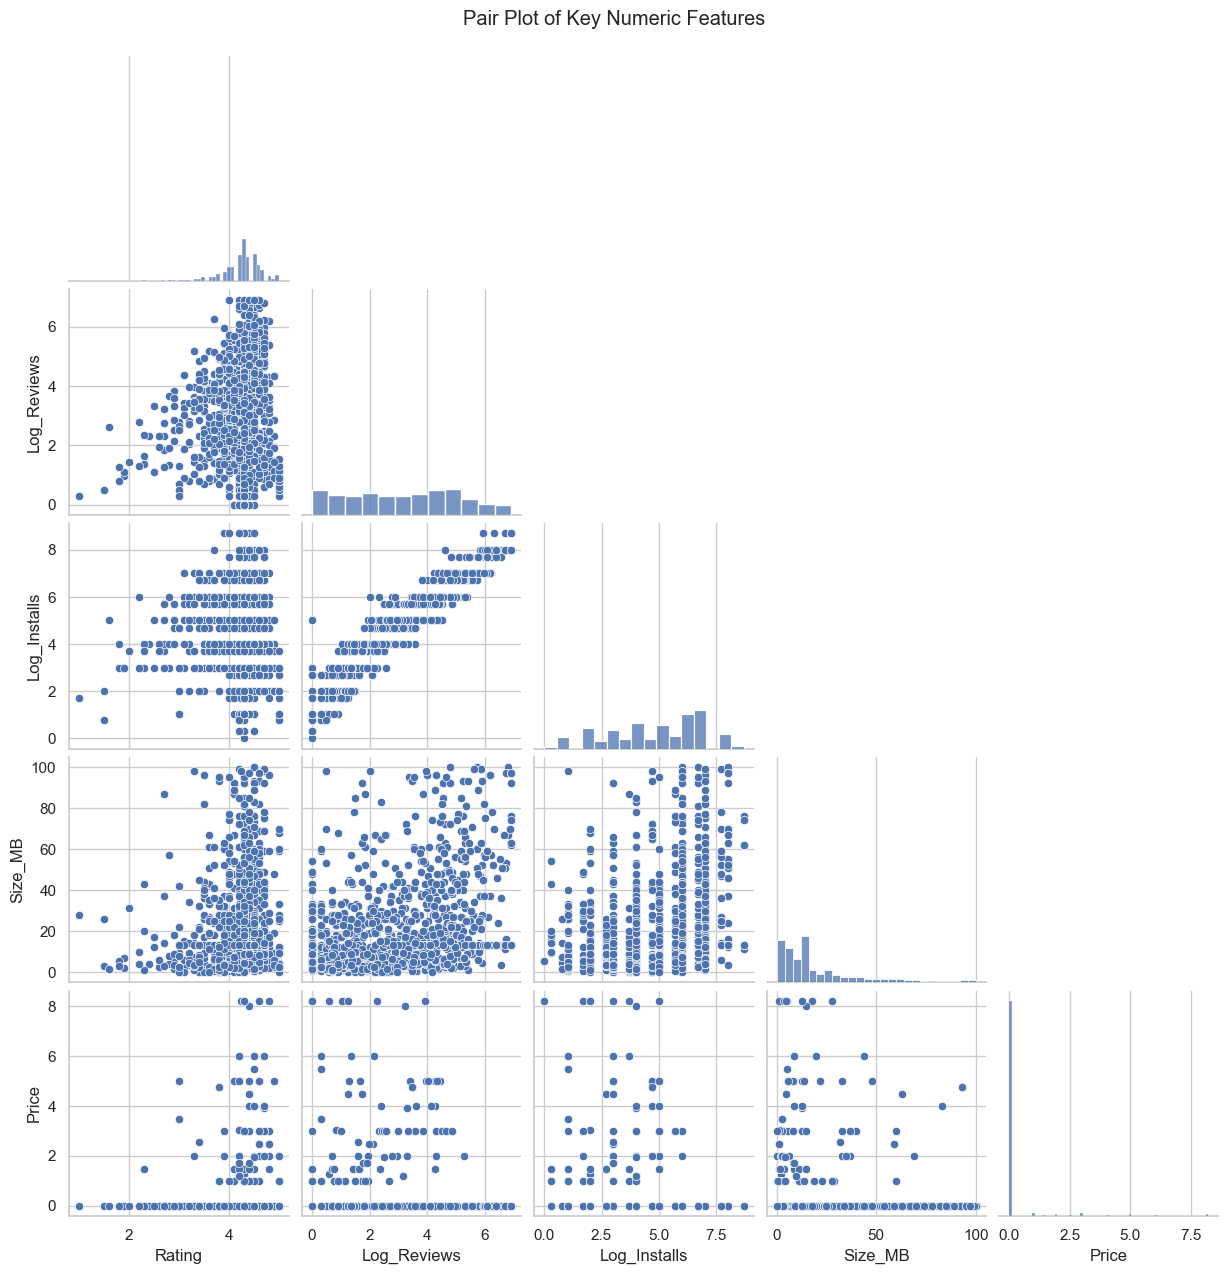

Welch t-test (Free vs Paid Ratings)
t-statistic: -4.1245
p-value    : 0.000041
Interpretation: Statistically significant difference


,Type,Count,Mean Rating,Std Rating
0,Free,9592,4.196612,0.484760
1,Paid,765,4.274052,0.500945


In [33]:
# Pair Plot visualization code
pair_cols = ['Rating', 'Log_Reviews', 'Log_Installs', 'Size_MB', 'Price']
pair_df = df_clean[pair_cols].sample(min(1200, len(df_clean)), random_state=42)
sns.pairplot(pair_df, diag_kind='hist', corner=True)
plt.suptitle('Pair Plot of Key Numeric Features', y=1.02)
plt.show()

# Statistical Analysis (Welch t-test): Free vs Paid rating
free_rating = df_clean.loc[df_clean['Type'] == 'Free', 'Rating'].dropna()
paid_rating = df_clean.loc[df_clean['Type'] == 'Paid', 'Rating'].dropna()

t_stat, p_value = stats.ttest_ind(free_rating, paid_rating, equal_var=False, nan_policy='omit')

print('Welch t-test (Free vs Paid Ratings)')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value    : {p_value:.6f}')
print('Interpretation:', 'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference')

pd.DataFrame({
    'Type': ['Free', 'Paid'],
    'Count': [free_rating.shape[0], paid_rating.shape[0]],
    'Mean Rating': [free_rating.mean(), paid_rating.mean()],
    'Std Rating': [free_rating.std(), paid_rating.std()]
})


##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?
Pair plot shows pairwise patterns and distribution behavior in one view.
##### 2. What is/are the insight(s) found from the chart?
It confirms skewness, install-review linkage, and weaker direct price-rating structure. Statistical test output adds inferential strength.


##### 2. What is/are the insight(s) found from the chart?

The chart supports multivariate reasoning and cross-checking of assumptions.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Insights and Findings**
- Installs and reviews are heavily right-skewed, indicating concentration of success among fewer apps.
- Category performance is uneven; demand is not uniformly distributed.
- Ratings matter, but adoption also depends on visibility, engagement, and category dynamics.
- Free apps dominate ecosystem share; paid apps are minority and likely niche-oriented.
- Correlation and t-test provide statistical support for observed behavioral differences.

**Business Recommendations**
- App developers: prioritize category-specific differentiation and maintain high rating hygiene.
- Product managers: track review velocity, update cadence, and install growth jointly as KPI bundle.
- Marketing teams: allocate spend to high-potential categories and optimize conversion funnels for free-to-paid value ladders.
- Investors: evaluate category concentration risk and favor apps with stable engagement and update discipline.


# **Conclusion**

The Play Store EDA demonstrates that app-market outcomes are shaped by a combination of quality signals, engagement strength, category positioning, and monetization design. After robust cleanup and analysis, the strongest practical pattern is the install-review relationship, while rating alone has moderate predictive value. Free apps dominate market presence, and category-level strategy is critical for growth. These insights can directly support product planning, marketing allocation, and portfolio investment decisions.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***